# Optimize the 2050 energy system with varying constraints on burden shifts

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import pickle

In [3]:
save_results = True
run_model = False
reg_level = 'spat_fore_back'
ssp_rcp = 'SSP2-L'

In [4]:
NOTEBOOK_DIR = Path.cwd()
LCA_PROJECTS_ROOT = NOTEBOOK_DIR.parent.parent
sys.path.insert(1, str(LCA_PROJECTS_ROOT / '02_Regionalization' / '01_Notebooks'))

In [5]:
from utils import (
    run_opti,
    add_biogenic_climate_change_to_impact_scores_df,
    add_rhhd_and_reqd_to_impact_scores_df,
    get_impact_scores,
    category_to_sector,
    aggregate_mobility_submodels,
    plot_configuration_sector,
    plot_contribution_by_sector,
    rename_bio_resources,
    techs_color_map,
    wood_list, wet_biomass_list, waste_list,
    LCA_DATA_FILES_DIR,
    AMPL_FILES_DIR,
    DATA_DIR,
    REF_RESULTS,
    N_capita_2050,
    run_order_burden_shifts,
)
import bw2data as bd
import pandas as pd
import ast

In [6]:
path_lca_data_2050 = AMPL_FILES_DIR / 'data' / '2050' / reg_level / ssp_rcp

In [7]:
impact_abbrev = pd.read_csv(DATA_DIR / 'impact_abbrev.csv')
impact_abbrev.Impact_category = impact_abbrev.Impact_category.apply(lambda x: ast.literal_eval(x))
model = pd.read_csv(DATA_DIR / 'model_2050.csv')
es_tech_df = pd.read_csv(DATA_DIR / 'technology_dictionary.csv')

In [8]:
es_tech_df = es_tech_df[~es_tech_df['Programming name'].isin(wood_list+wet_biomass_list+waste_list)]  # keeping ES names for aggregation of biomass resources later on
es_tech_name_dict = dict(zip(es_tech_df['Programming name'], es_tech_df['Long name']))

## Define scenarios and run the model

In [9]:
scenarios = {
    'All': {'limit_rhh': True, 'limit_req': True, 'limit_acc': True},
    'CCA REQ': {'limit_rhh': False, 'limit_req': True, 'limit_acc': True},
    'CCA RHH': {'limit_rhh': True, 'limit_req': False, 'limit_acc': True},
    'CCA': {'limit_rhh': False, 'limit_req': False, 'limit_acc': True},
    'RHH REQ': {'limit_rhh': True, 'limit_req': True, 'limit_acc': False},
    'REQ': {'limit_rhh': False, 'limit_req': True, 'limit_acc': False},
    'RHH': {'limit_rhh': True, 'limit_req': False, 'limit_acc': False},
    'None': {'limit_rhh': False, 'limit_req': False, 'limit_acc': False},
}

In [10]:
results_dict = {}

if run_model:
    for scenario, constraints in scenarios.items():
        results_dict[scenario] = {}
        results_dict[scenario]['results'] = run_opti(
            reg_level=reg_level,
            ssp_rcp=ssp_rcp,
            constraint_on_remaining_hh=constraints['limit_rhh'],
            constraint_on_remaining_eq=constraints['limit_req'],
            constraint_on_foreign_ghg_emissions=constraints['limit_acc'],
            constraint_on_territorial_ghg_emissions=True,
        )
        if save_results:
            with open(f"../03_Results/Pickle/results_{scenario.replace(' ', '_')}.pkl", 'wb') as f:
                pickle.dump(results_dict[scenario]['results'], f)

else:
    # To skip the optimization part
    for scenario in scenarios.keys():
        with open(f"../03_Results/Pickle/results_{scenario.replace(' ', '_')}.pkl", 'rb') as f:
            results_dict[scenario] = {}
            results_dict[scenario]['results'] = pickle.load(f)

## Extract results

In [11]:
bd.projects.set_current('ecoinvent3.10.1')

In [12]:
impact_scores = pd.read_csv(LCA_DATA_FILES_DIR / '2050' / reg_level / ssp_rcp / 'impact_scores.csv')
impact_scores_direct = pd.read_csv(LCA_DATA_FILES_DIR / '2050' / reg_level / ssp_rcp / 'impact_scores_direct_emissions.csv')
norm_factors = pd.read_csv(path_lca_data_2050 / 'QC_techs_lca_max.csv')
max_ccs_norm = norm_factors.set_index('Abbrev').loc['m_CCS_all']['max_unit']

In [13]:
limits = {
    'RHH': results_dict['All']['results'].parameters['limit_lcia'].loc['RHHD']['limit_lcia'],
    'REQ': results_dict['All']['results'].parameters['limit_lcia'].loc['REQD']['limit_lcia'],
    'CCA': results_dict['All']['results'].parameters['limit_abroad'].loc['m_CCS_all']['limit_abroad'],
}

In [14]:
limits['CCA'] *= norm_factors.set_index('Abbrev').loc['m_CCS_all']['max_unit']
limits['RHH'] *= norm_factors.set_index('Abbrev').loc['RHHD']['max_unit']
limits['REQ'] *= norm_factors.set_index('Abbrev').loc['REQD']['max_unit']

In [15]:
impact_categories_list = [
    i for i in bd.methods if
    (i[0] == 'IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10')
    | (i[0] == 'IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10')
    | (i[0] == 'IMPACT World+ Midpoint 2.1 for ecoinvent v3.10 (incl. CO2 uptake)')
    | (i[0] == 'IMPACT World+ Damage 2.1 for ecoinvent v3.10 (incl. CO2 uptake)')
]

impact_categories_list +=[
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Remaining ecosystem quality'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Human health', 'Remaining human health'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Total ecosystem quality (biogenic)'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Human health', 'Total human health (biogenic)'),
]

impact_categories_list = [i for i in impact_categories_list if i not in [  # keep only marine acidification from -1/+1 version of IW+
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Marine acidification, short term'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Marine acidification, long term')
]]

In [16]:
impact_scores, impact_abbrev = add_biogenic_climate_change_to_impact_scores_df(impact_scores, impact_abbrev)
impact_scores_direct = add_biogenic_climate_change_to_impact_scores_df(impact_scores_direct, impact_abbrev)[0]

impact_scores, impact_abbrev = add_rhhd_and_reqd_to_impact_scores_df(impact_scores, impact_abbrev)
impact_scores_direct = add_rhhd_and_reqd_to_impact_scores_df(impact_scores_direct, impact_abbrev)[0]

In [17]:
def get_lca_scores(scenario, results):

    df_f_mult, df_annual_prod, df_annual_res = get_impact_scores(
        impact_category=impact_categories_list,
        df_impact_scores=impact_scores,
        df_results=results,
    )

    df_annual_prod_direct = get_impact_scores(
        impact_category=impact_categories_list,
        df_impact_scores=impact_scores_direct,
        df_results=results,
        assessment_type='direct',
    )

    df_f_mult['Run'] = scenario
    df_annual_prod['Run'] = scenario
    df_annual_res['Run'] = scenario
    df_annual_prod_direct['Run'] = scenario

    df_f_mult = df_f_mult[df_f_mult.F_Mult != 0]
    df_annual_prod = df_annual_prod[df_annual_prod.Annual_Prod != 0]
    df_annual_res = df_annual_res[df_annual_res.Annual_Res != 0]
    df_annual_prod_direct = df_annual_prod_direct[df_annual_prod_direct.Annual_Prod != 0]

    df_annual_prod = df_annual_prod.merge(
        results.variables['ABROAD_op'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'ABROAD_op': 'Climate change, short term, total (abroad)'})
    df_annual_prod = df_annual_prod.merge(
        results.variables['TERRITORIAL_op'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'TERRITORIAL_op': 'Climate change, short term, total (territorial)'})
    df_f_mult = df_f_mult.merge(
        results.variables['ABROAD_constr'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'ABROAD_constr': 'Climate change, short term, total (abroad)'})
    df_f_mult = df_f_mult.merge(
        results.variables['TERRITORIAL_constr'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'TERRITORIAL_constr': 'Climate change, short term, total (territorial)'})
    df_annual_res = df_annual_res.merge(
        results.variables['ABROAD_res'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'ABROAD_res': 'Climate change, short term, total (abroad)'})
    df_annual_res = df_annual_res.merge(
        results.variables['TERRITORIAL_res'].loc['m_CCS_all'].drop(columns=['Run']) * max_ccs_norm, left_on='index', right_index=True,
    ).rename(columns={'TERRITORIAL_res': 'Climate change, short term, total (territorial)'})

    df_f_mult = df_f_mult.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_annual_prod = df_annual_prod.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_annual_prod_direct = df_annual_prod_direct.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_f_mult['Main production'] = df_f_mult['Main production'].astype(str)
    df_annual_prod['Main production'] = df_annual_prod['Main production'].astype(str)
    df_annual_prod_direct['Main production'] = df_annual_prod_direct['Main production'].astype(str)

    df_annual_prod['Sector'] = df_annual_prod.apply(category_to_sector, axis=1)
    df_annual_prod_direct['Sector'] = df_annual_prod_direct.apply(category_to_sector, axis=1)
    df_f_mult['Sector'] = df_f_mult.apply(category_to_sector, axis=1)
    df_annual_res['Sector'] = df_annual_res.apply(lambda x: 'Electricity' if x['index'] == 'ELECTRICITY_EHV' else ('Biomass' if x['index'] in wood_list+wet_biomass_list+waste_list else 'Imports'), axis=1)
    df_annual_res['Category'] = df_annual_res.apply(lambda x: 'ELECTRICITY_EHV' if x['index'] == 'ELECTRICITY_EHV' else ('Biomass' if x['index'] in wood_list+wet_biomass_list+waste_list else 'Imports'), axis=1)

    return df_f_mult, df_annual_prod, df_annual_res, df_annual_prod_direct

In [18]:
for scenario in scenarios.keys():
    results = results_dict[scenario]['results']
    (
        results_dict[scenario]['df_f_mult'],
        results_dict[scenario]['df_annual_prod'],
        results_dict[scenario]['df_annual_res'],
        results_dict[scenario]['df_annual_prod_direct'],
    ) = get_lca_scores(scenario, results)

In [19]:
df_f_mult = pd.concat([results_dict[run]['df_f_mult'] for run in scenarios])
df_annual_prod = pd.concat([results_dict[run]['df_annual_prod'] for run in scenarios])
df_annual_res = pd.concat([results_dict[run]['df_annual_res'] for run in scenarios])
df_annual_prod_direct = pd.concat([results_dict[run]['df_annual_prod_direct'] for run in scenarios])

In [20]:
cat_list = [i[-1] for i in impact_categories_list if
            i[1] in ['Human health', 'Ecosystem quality']
            and i[-1] not in ['Total human health', 'Total ecosystem quality']
            ] + ['Climate change, short term, total', 'Climate change, short term, total (territorial)', 'Climate change, short term, total (abroad)']

df_annual_prod_indirect = df_annual_prod.merge(df_annual_prod_direct, on=['index', 'Run', 'Sector', 'Category', 'Annual_Prod'], suffixes=('', ' (direct)'), how='left')
for col in list(df_annual_prod.columns):
    if col not in ['index', 'Run', 'Sector', 'Category', 'Annual_Prod', 'Phase', 'Main production']:
        if col in ['Climate change, short term, total (territorial)', 'Climate change, short term, total (abroad)']:
            df_annual_prod_direct[col] = 0  # phases are won't be used for these two categories
        else:
            df_annual_prod_indirect[col] = df_annual_prod_indirect[col] - df_annual_prod_indirect[f"{col} (direct)"]
            df_annual_prod_indirect.drop(columns=[f"{col} (direct)"], inplace=True)

df_annual_prod_indirect = df_annual_prod_indirect[['index', 'Run', 'Sector', 'Category', 'Annual_Prod'] + cat_list]

col = ['Run', 'index', 'Sector', 'Phase'] + cat_list
df_f_mult['Phase'] = 'Construction'
df_annual_prod['Phase'] = 'Operation'
df_annual_prod_direct['Phase'] = 'Operation (direct)'
df_annual_prod_indirect['Phase'] = 'Operation (indirect)'
df_annual_res['Phase'] = 'Resource'

df_total_impact = pd.concat([
    df_f_mult[['F_Mult'] + col].rename(columns={'F_Mult': 'Capacity or production'}),
    df_annual_prod_direct[['Annual_Prod'] + col].rename(columns={'Annual_Prod': 'Capacity or production'}),
    df_annual_prod_indirect[['Annual_Prod'] + col].rename(columns={'Annual_Prod': 'Capacity or production'}),
    df_annual_res[['Annual_Res'] + col].rename(columns={'Annual_Res': 'Capacity or production'}),
],
    ignore_index=True)



In [21]:
all_mob_techs = (
    list(results_dict['All']['results'].sets['TECHNOLOGIES_OF_FREIGHTMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_FREIGHTMOB_ALL_DISTANCES'])
    + list(results_dict['All']['results'].sets['TECHNOLOGIES_OF_PRIVATEMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_PRIVATEMOB_ALL_DISTANCES'])
    + list(results_dict['All']['results'].sets['TECHNOLOGIES_OF_PUBLICMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_PUBLICMOB_ALL_DISTANCES'])
)

# Keeping mobility sub-models only for production and impact dataframe (main models are kept if df_f_mult because they have the cost data)
df_total_impact = df_total_impact[~df_total_impact['index'].isin(all_mob_techs)]
df_annual_prod = df_annual_prod[~df_annual_prod['index'].isin(all_mob_techs)]
df_annual_prod_direct = df_annual_prod_direct[~df_annual_prod_direct['index'].isin(all_mob_techs)]

df_total_impact = aggregate_mobility_submodels(df_total_impact)
df_annual_prod = aggregate_mobility_submodels(df_annual_prod)
df_annual_prod_direct = aggregate_mobility_submodels(df_annual_prod_direct)

df_total_impact['index'] = df_total_impact['index'].replace(es_tech_name_dict)
df_annual_prod['index'] = df_annual_prod['index'].replace(es_tech_name_dict)
df_f_mult['index'] = df_f_mult['index'].replace(es_tech_name_dict)
df_annual_res['index'] = df_annual_res['index'].replace(es_tech_name_dict)
df_annual_prod_direct['index'] = df_annual_prod_direct['index'].replace(es_tech_name_dict)

In [22]:
if save_results:
    df_f_mult.to_csv('../03_Results/Tables/df_f_mult.csv', index=False)
    df_annual_prod.to_csv('../03_Results/Tables/df_annual_prod.csv', index=False)
    df_annual_res.to_csv('../03_Results/Tables/df_annual_res.csv', index=False)
    df_annual_prod_direct.to_csv('../03_Results/Tables/df_annual_prod_direct.csv', index=False)
    df_total_impact.to_csv('../03_Results/Tables/df_total_impact.csv', index=False)

## Plot the results

### Configurations

In [23]:
import plotly.io as pio
import plotly.express as px
import plotly.graph_objs as go
pio.renderers.default = "png"

In [24]:
for distance_level in ['_SD', '_MD', '_LD', '_ELD']:
    model['Name'] = model['Name'].str.replace(distance_level, '')
    model['Flow'] = model['Flow'].str.replace(distance_level, '')
model.drop_duplicates(inplace=True)

model['Name'] = model['Name'].replace(es_tech_name_dict)

In [25]:
df_annual_res_2023 = pd.read_csv(REF_RESULTS / 'df_annual_res.csv')
df_annual_prod_2023 = pd.read_csv(REF_RESULTS / 'df_annual_prod.csv')
df_f_mult_2023 = pd.read_csv(REF_RESULTS / 'df_f_mult.csv')

df_annual_prod_2023 = aggregate_mobility_submodels(df_annual_prod_2023)
df_annual_prod_2023['index'] = df_annual_prod_2023['index'].replace(es_tech_name_dict)
df_f_mult_2023 = aggregate_mobility_submodels(df_f_mult_2023)
df_f_mult_2023['index'] = df_f_mult_2023['index'].replace(es_tech_name_dict)

In [26]:
show_delta = False

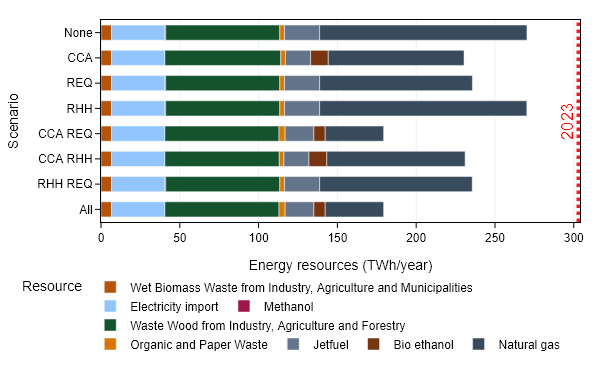

In [27]:
df_res = df_annual_res[(df_annual_res.Annual_Res > 0.1) & (df_annual_res['index'] != 'CO2_E')]
df_res = df_res.apply(lambda row: rename_bio_resources(row, name_type='long'), axis=1)
df_res['Annual_Res'] *= 1e-3  # from GWh to TWh
df_res = df_res[
    ~((df_res['index'].str.startswith('RES_')) | (df_res['index'].str.contains('potential')))
].groupby(['Run', 'index']).sum().reset_index()
df_res = pd.merge(df_res, df_res.groupby('index')[['Annual_Res']].std().reset_index(), how='left', on='index', suffixes=('', '_std'))
df_res = pd.merge(df_res, df_res.groupby('index')[['Annual_Res']].mean().reset_index(), how='left', on='index', suffixes=('', '_mean'))
df_res['Annual_Res_cov'] = df_res['Annual_Res_std'] / df_res['Annual_Res_mean']
df_res = df_res.sort_values('Annual_Res_cov', ascending=True)

df_res_2023 = df_annual_res_2023[df_annual_res_2023['Run'] == "base"]
df_res_2023 = df_res_2023[~df_res_2023['index'].str.startswith('RES_')]
df_res_2023['Annual_Res'] *= 1e-3  # from GWh to TWh
total_res_2023 = float(df_res_2023['Annual_Res'].sum())
df_res['Sector'] = 'Energy resources'
df_res['Unit'] = 'TWh/year'

if show_delta:
    # Get the reference data (default scenario)
    df_def = df_res[df_res['Run'] == 'None'][['index', 'Run', 'Annual_Res']].copy()
    total_res_def = float(df_def['Annual_Res'].sum())

    # Ensure every Name in the reference has an entry for every Run in df_res
    for name in df_def['index'].unique():
        for run in df_res['Run'].unique():
            if run != 'None':  # Skip the default run
                if len(df_res[(df_res['index'] == name) & (df_res['Run'] == run)]) == 0:
                    # Add a row with Annual_Res=0
                    new_row = {'index': name, 'Run': run, 'Annual_Res': 0}
                    df_res = pd.concat([df_res, pd.DataFrame([new_row])], ignore_index=True)

    df_res = df_res.merge(df_res[df_res['Run'] == 'None'][['index', 'Run', 'Annual_Res']], how='outer', on=['index'], suffixes=('', '_def'))
    df_res['Annual_Res_def'] = df_res['Annual_Res_def'].fillna(0)
    df_res['Annual_Res'] = df_res['Annual_Res'].fillna(0)
    df_res['Delta'] = df_res['Annual_Res'] - df_res['Annual_Res_def']
    df_res['Delta_perc'] = 100 * df_res['Delta'] / total_res_def
    df_res = df_res[df_res['Run'] != 'None']

hover_vars = ['Run_hover', 'index', 'Annual_Res']
fig = px.bar(
    df_res,
    y='Run',
    x='Annual_Res' if not show_delta else 'Delta_perc',
    orientation='h',
    color='index',
    color_discrete_map=techs_color_map,
    width=600,
    height=370,
    category_orders={
        'Run': [i.replace('\n', ' ') for i in ['None', 'CCA', 'REQ', 'RHH', 'CCA REQ', 'CCA RHH', 'RHH REQ', 'All']],
    },
    labels={
        'Run': 'Scenario',
        'Annual_Res': 'Energy resources (TWh/year)',
        'index': 'Resource',
        'Delta': 'Difference with default in energy resources (TWh/year)',
        'Delta_perc': f'Difference with default in energy resources (%)',
    },
    # hover_data=hover_vars,
)
# hover_text = (
#     f"<b>Prosp.-reg. level:</b> %{{customdata[0]}}<br>"
#     f"<b>Resource:</b> %{{customdata[1]}}<br>"
# )

# hover_text += f"<b>Value:</b> %{{x:,.2f}} {'TWh / year' if not show_delta else '%'}<extra></extra>"

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    # legend_traceorder="reversed",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.25,
        xanchor="center",
        x=0.4,
    )
)

fig.update_traces(
    width=.6,
    # hovertemplate=hover_text,
)

if not show_delta:
    fig.add_vline(
        x=total_res_2023,
        line_dash="dot",
        line_color="red",
        line_width=3.5,
        opacity=0.9,
        label=dict(text="2023", font=dict(color="red", size=17))
    )

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/annual_res{"_delta" if show_delta else ""}.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(f'../03_Results/Figures/annual_res{"_delta" if show_delta else ""}.html')

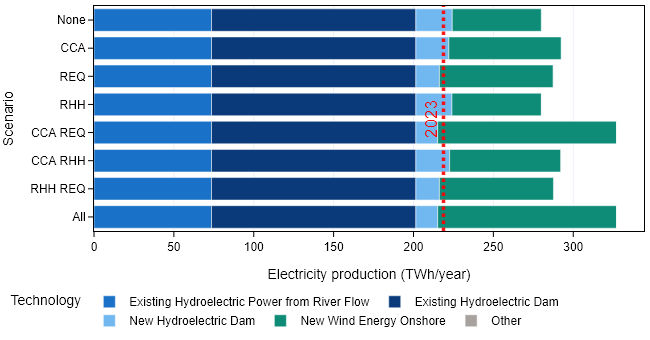

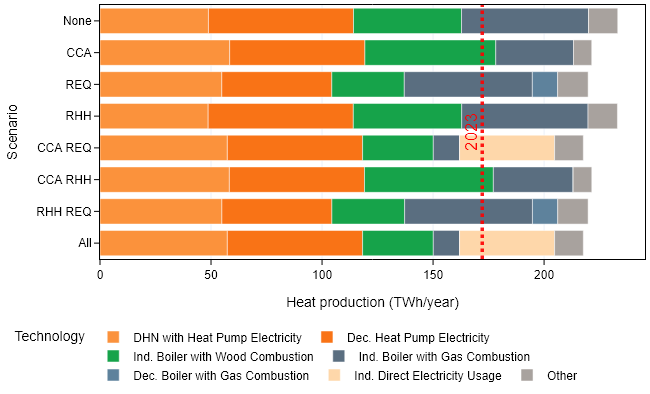

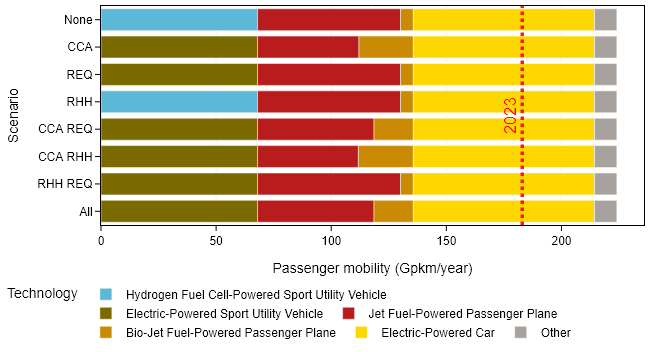

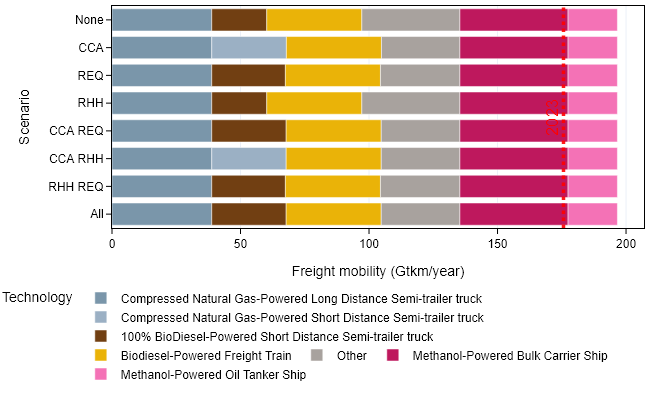

C:\Users\matth\PycharmProjects\EnergyScope-Quebec\projects\lca\02_Regionalization\01_Notebooks\utils.py:2443: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



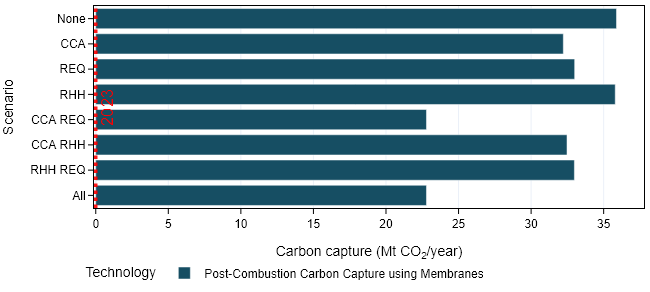

C:\Users\matth\PycharmProjects\EnergyScope-Quebec\projects\lca\02_Regionalization\01_Notebooks\utils.py:2443: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



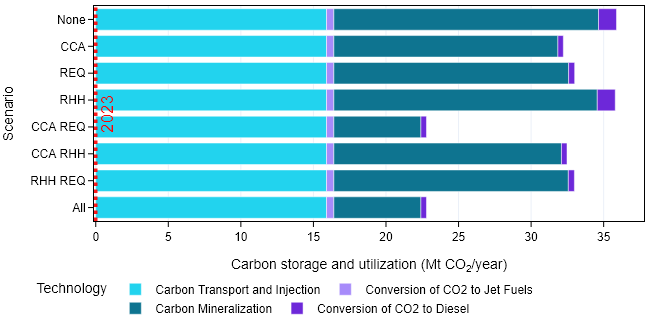

C:\Users\matth\PycharmProjects\EnergyScope-Quebec\projects\lca\02_Regionalization\01_Notebooks\utils.py:2443: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



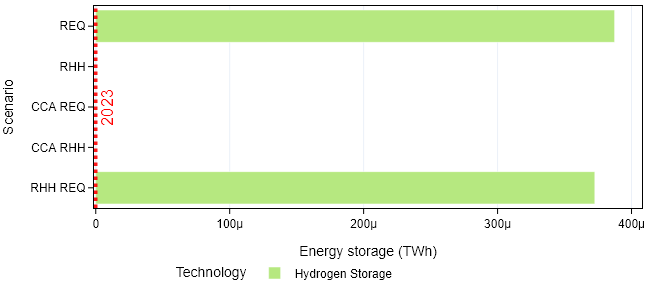

C:\Users\matth\PycharmProjects\EnergyScope-Quebec\projects\lca\02_Regionalization\01_Notebooks\utils.py:2443: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



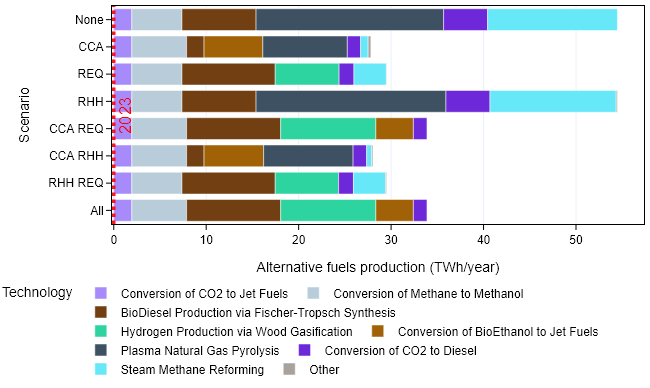

In [28]:
cutoff_dict = {
    'Electricity': 0.03,
    'Heat': 0.03,
    'Passenger mobility': 0.04,
    'Freight mobility': 0.08,
    'Carbon capture': 0,
    'Carbon storage and utilization': 0,
    'Storage': 0,
    'Other': 0.02,
}

for sector in ['Electricity', 'Heat', 'Passenger mobility', 'Freight mobility', 'Carbon capture', 'Carbon storage and utilization', 'Storage', 'Other']:
    fig = plot_configuration_sector(
        model=model,
        annual_prod=df_annual_prod,
        annual_prod_2023=df_annual_prod_2023,
        sector=sector,
        show_delta=show_delta,
        save_results=False,
        scenario=True,
        return_fig=True,
        show_fig=True,
        cutoff=cutoff_dict[sector],
    )

    if save_results:
        fig.write_image(f'../03_Results/Figures/annual_prod_{sector.lower().replace(" ", "_")}{"_delta" if show_delta else ""}.pdf')
        fig.update_layout(width=None, height=None)
        fig.write_html(
            f'../03_Results/Figures/annual_prod_{sector.lower().replace(" ", "_")}{"_delta" if show_delta else ""}.html',
            include_plotlyjs=True,
            full_html=True,
        )

### Impacts

#### Climate change

In [29]:
df_total_impact['Climate change, short term, total'] *= 1e3 / N_capita_2050  # convert to t CO2 eq. per capita and per year
df_total_impact['Climate change, short term, total (abroad)'] *= 1e3 / N_capita_2050
df_total_impact['Climate change, short term, total (territorial)'] *= 1e3 / N_capita_2050
limits['CCA'] *= 1e3 / N_capita_2050

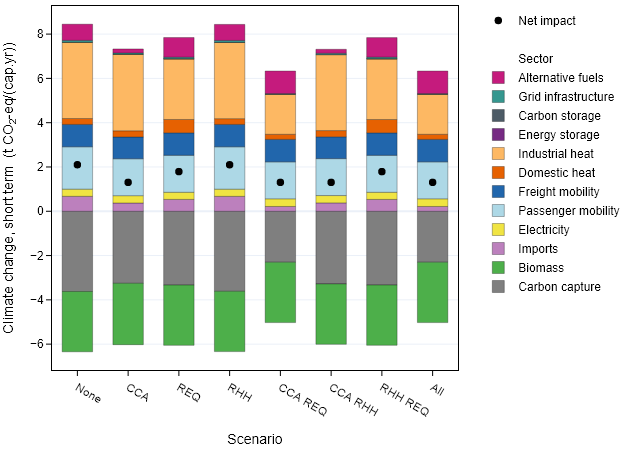

In [30]:
plot_contribution_by_sector(
    df=df_total_impact,
    show_direct_marker=False,
    show_total_marker=True,
    imp_cat='Climate change, short term, total',
    save_results=save_results,
    hatch_phase=False,
    showlegend=True,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

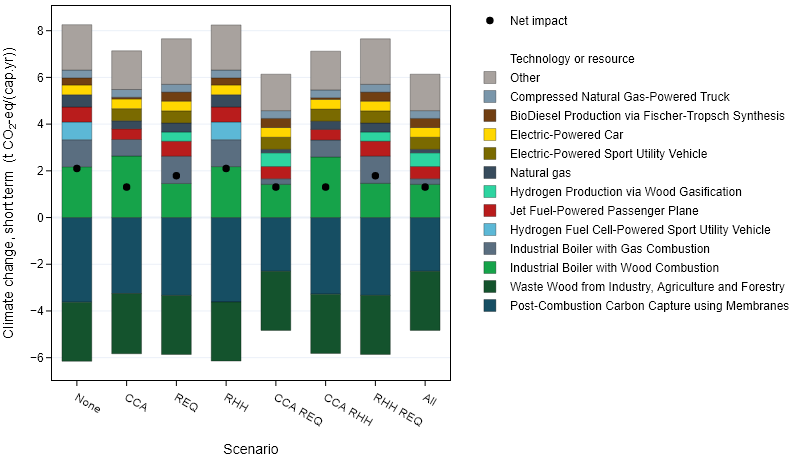

In [31]:
plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total',
    save_results=save_results,
    group_by='index',
    cutoff=0.028,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    hatch_phase=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

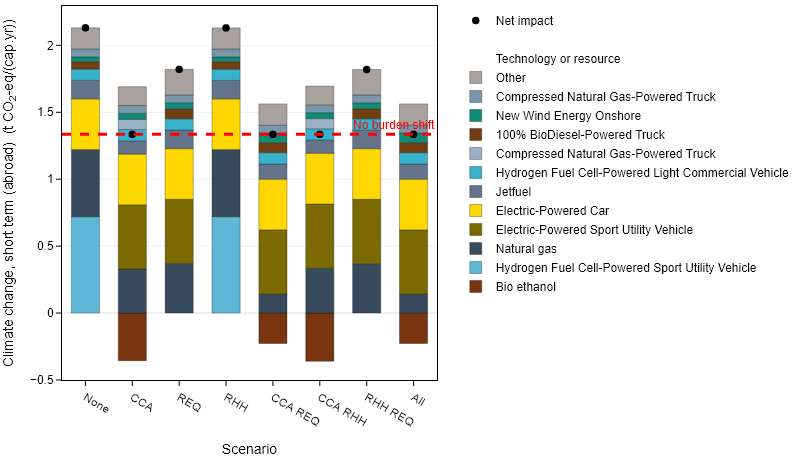

In [32]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total (abroad)',
    save_results=False,
    group_by='index',
    cutoff=0.025,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    hatch_phase=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['CCA'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/index_contrib_climate_change_short_term_abroad_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/index_contrib_climate_change_short_term_abroad_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

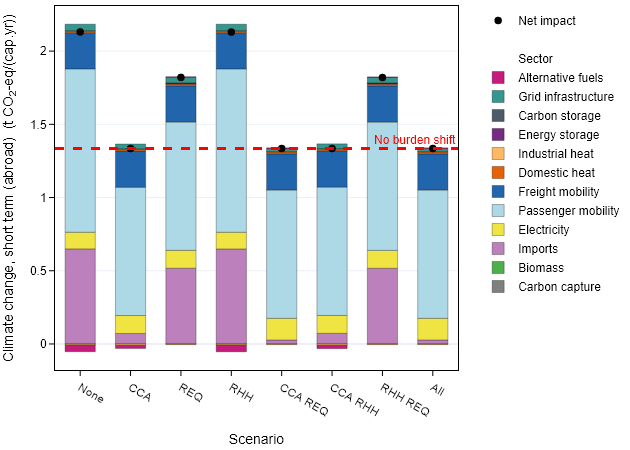

In [33]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total (abroad)',
    save_results=False,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    hatch_phase=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['CCA'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/Sector_contrib_climate_change_short_term_abroad_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/Sector_contrib_climate_change_short_term_abroad_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

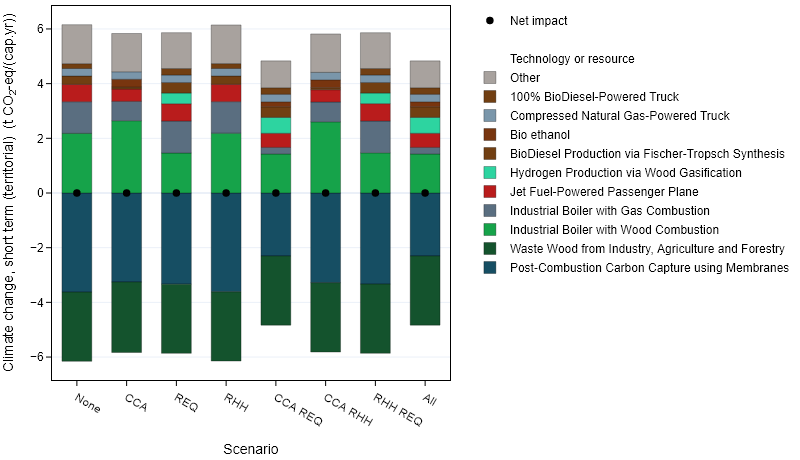

In [34]:
plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total (territorial)',
    save_results=save_results,
    group_by='index',
    cutoff=0.022,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    hatch_phase=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

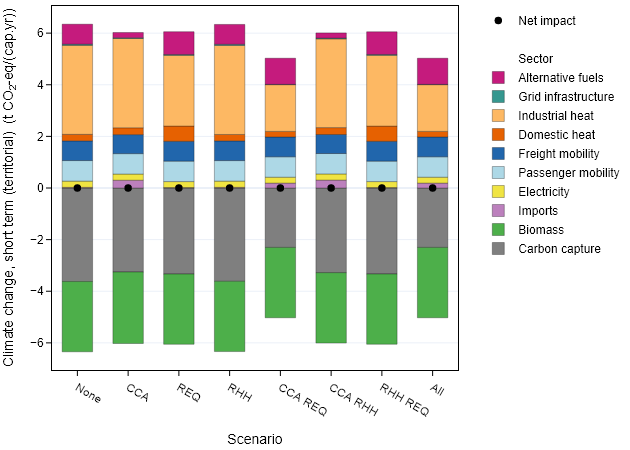

In [35]:
plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total (territorial)',
    save_results=save_results,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    hatch_phase=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

#### Human health

In [36]:
df_total_impact['Total human health (biogenic)'] *= 1e6 / N_capita_2050
df_total_impact['Remaining human health'] *= 1e6 / N_capita_2050
limits['RHH'] *= 1e6 / N_capita_2050

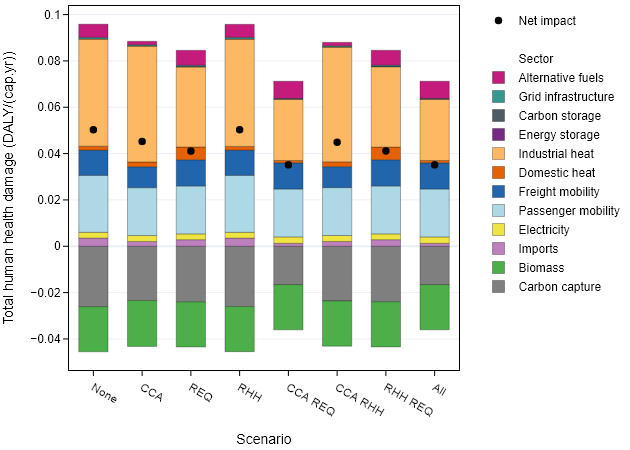

In [37]:
plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total human health (biogenic)': 'Total human health'}),
    imp_cat='Total human health',
    save_results=save_results,
    show_direct_marker=False,
    show_regionalized_marker=False,
    showlegend=True,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

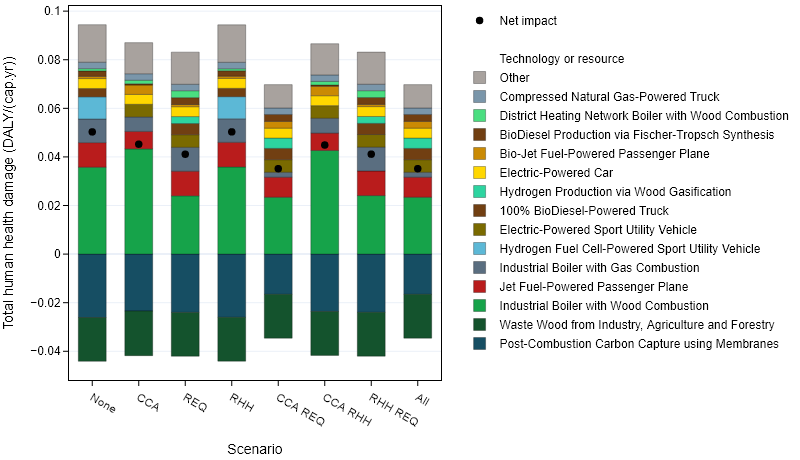

In [38]:
plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total human health (biogenic)': 'Total human health'}),
    imp_cat='Total human health',
    save_results=save_results,
    group_by='index',
    cutoff=0.02,
    showlegend=True,
    show_direct_marker=False,
    show_regionalized_marker=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

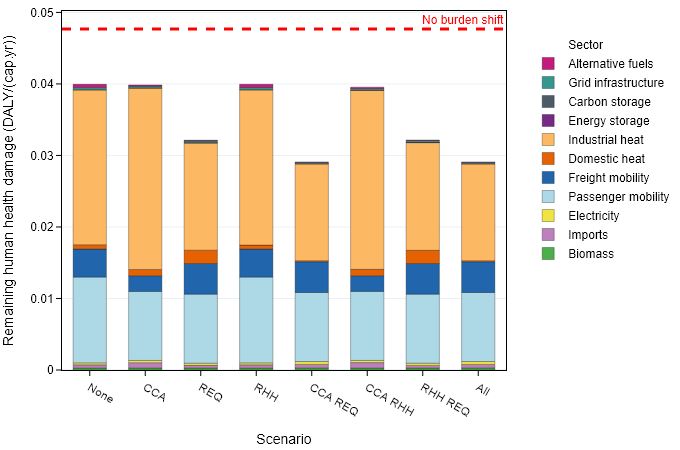

In [39]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Remaining human health',
    save_results=False,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['RHH'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/Sector_contrib_remaining_human_health_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/Sector_contrib_remaining_human_health_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

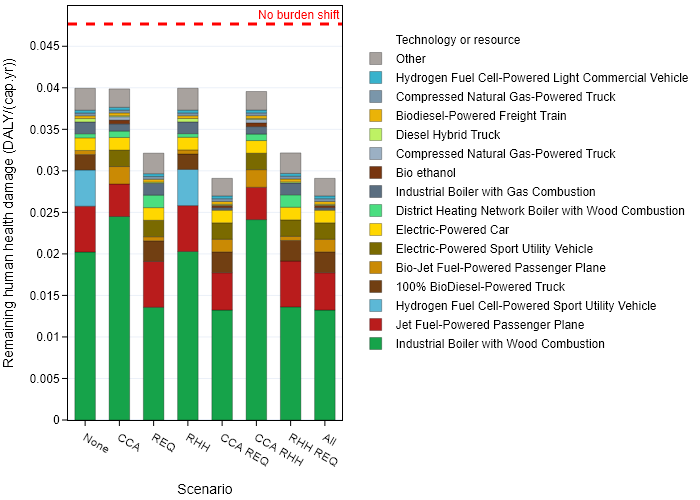

In [40]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Remaining human health',
    save_results=save_results,
    group_by='index',
    cutoff=0.01,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['RHH'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/index_contrib_remaining_human_health_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/index_contrib_remaining_human_health_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

#### Ecosystem quality

In [41]:
df_total_impact['Total ecosystem quality (biogenic)'] *= 1e6 / N_capita_2050
df_total_impact['Remaining ecosystem quality'] *= 1e6 / N_capita_2050
limits['REQ'] *= 1e6 / N_capita_2050

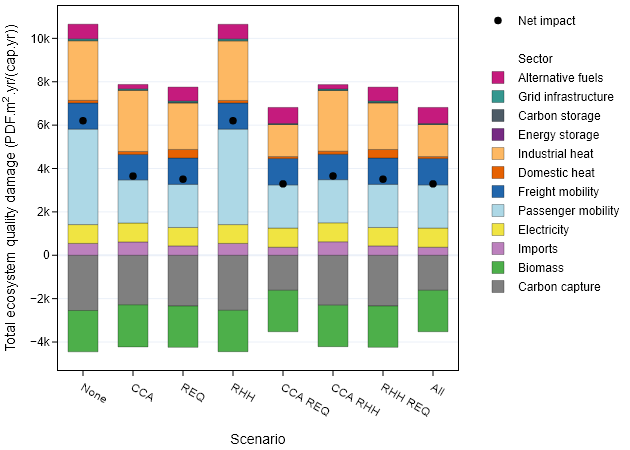

In [42]:
plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total ecosystem quality (biogenic)': 'Total ecosystem quality'}),
    imp_cat='Total ecosystem quality',
    save_results=save_results,
    show_direct_marker=False,
    show_regionalized_marker=False,
    showlegend=True,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

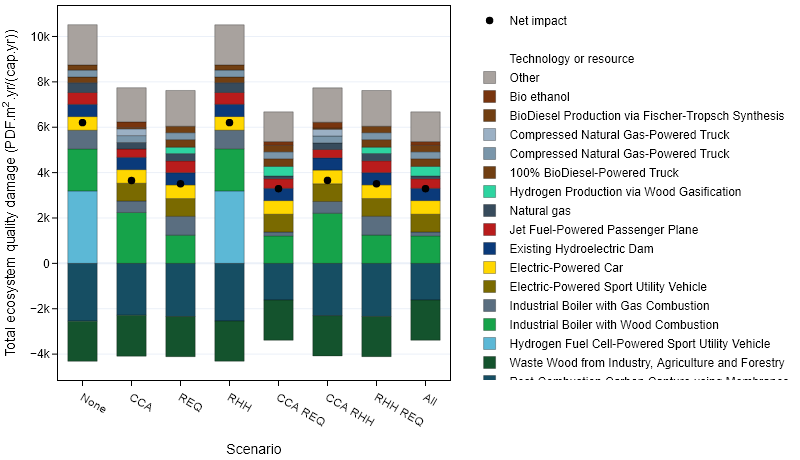

In [43]:
plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total ecosystem quality (biogenic)': 'Total ecosystem quality'}),
    imp_cat='Total ecosystem quality',
    save_results=save_results,
    group_by='index',
    cutoff=0.02,
    showlegend=True,
    show_direct_marker=False,
    show_regionalized_marker=False,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
)

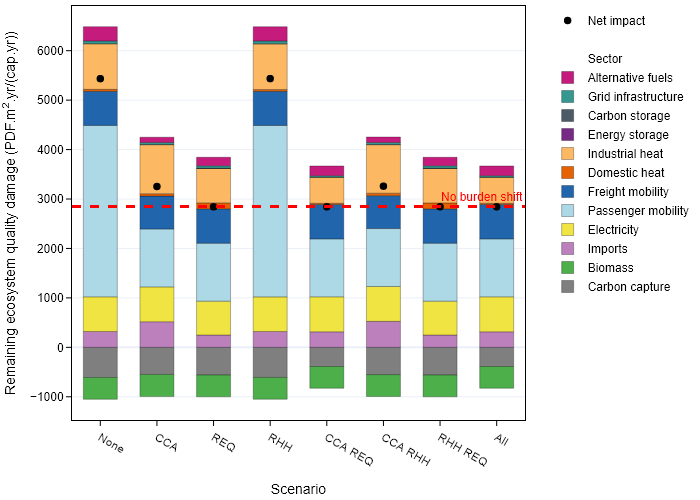

In [44]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Remaining ecosystem quality',
    save_results=save_results,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['REQ'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/Sector_contrib_remaining_ecosystem_quality_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/Sector_contrib_remaining_ecosystem_quality_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

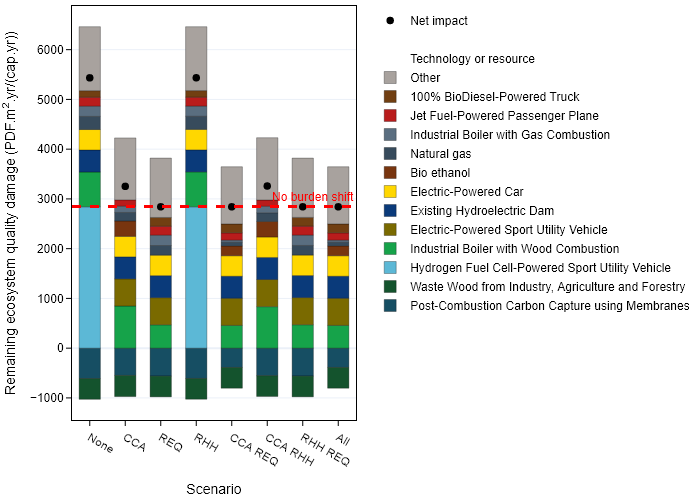

In [45]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Remaining ecosystem quality',
    save_results=save_results,
    group_by='index',
    cutoff=0.03,
    showlegend=True,
    show_direct_marker=False,
    show_total_marker=True,
    multiple_rcp=False,
    study='burden',
    x_label_name='Scenario',
    return_fig=True,
    show_fig=False,
)

fig.add_hline(y=limits['REQ'], line_width=3, line_dash="dash", line_color='red', annotation_text='No burden shift', annotation=dict(font_color='red'))

fig.show()

if save_results:
    fig.write_image(f'../03_Results/Figures/index_contrib_remaining_ecosystem_quality_2050.pdf')
    fig.update_layout(width=None, height=None)
    fig.write_html(
        f'../03_Results/Figures/index_contrib_remaining_ecosystem_quality_2050.html',
        include_plotlyjs=True,
        full_html=True,
    )

### Cost

In [46]:
tc_dict = {scenario: results_dict[scenario]['results'].variables['TotalCost']['TotalCost'].iloc[0] for scenario in scenarios.keys()}

In [47]:
delta_rel_dict = {scenario: 100 * (tc_dict[scenario] - tc_dict['None']) / tc_dict['None'] for scenario in scenarios.keys()}

In [48]:
delta_rel_dict

{'All': 2.5729423607895803,
 'CCA REQ': 2.5729423607896167,
 'CCA RHH': 2.088868298902065,
 'CCA': 2.0960522286875314,
 'RHH REQ': 0.3324426049703356,
 'REQ': 0.33191031633933843,
 'RHH': 0.00613334249418907,
 'None': 0.0}

In [49]:
def plot_cost_difference(
        df_f_mult: pd.DataFrame,
        df_annual_res: pd.DataFrame,
        cutoff: float = 0,
        relative: bool = True,
        save_results: bool = save_results,
):

    df_f_mult['Cost'] = df_f_mult['C_inv_an'] + df_f_mult['C_maint']
    df_cost = pd.concat([df_f_mult[['Run', 'index', 'Cost']], df_annual_res[['Run', 'index', 'C_op']].rename(columns={'C_op': 'Cost'})])
    df_cost['Cost'] *= 1e6 / N_capita_2050  # from MCAD to CAD/cap

    # Ensure every index in the reference has an entry for every Run in df_cost
    for name in df_cost['index'].unique():
        for run in df_cost['Run'].unique():
            if run != 'None':  # Skip the default run
                if len(df_cost[(df_cost['index'] == name) & (df_cost['Run'] == run)]) == 0:
                    # Add a row with Production=0
                    new_row = {'index': name, 'Run': run, 'Cost': 0}
                    df_cost = pd.concat([df_cost, pd.DataFrame([new_row])], ignore_index=True)

    df_cost = pd.merge(
        df_cost,
        df_cost[df_cost['Run'] == 'None'][['index', 'Cost']],
        on=['index'],
        how='left',
        suffixes=('', '_ref'),
    )

    df_cost['Cost_ref'] = df_cost['Cost_ref'].fillna(0)
    df_cost['Delta'] = df_cost['Cost'] - df_cost['Cost_ref']
    df_cost['Delta_rel'] = 100 * df_cost['Delta'] / df_cost[df_cost['Run'] == 'None']['Cost'].sum()

    # Apply cutoff
    df_cost['index'] = df_cost.apply(lambda x: x['index'] if abs(x['Delta_rel']) >= cutoff else 'Other', axis=1)

    # Sort bars
    df_grouped_index = df_cost.groupby(['Run', 'index'])['Delta'].sum().reset_index()
    index_order = [
                      tec for tec in
                      df_grouped_index[df_grouped_index['Delta'] < 0].sort_values(by='Delta', ascending=False)['index'].unique().tolist() +
                      df_grouped_index[df_grouped_index['Delta'] > 0].sort_values(by='Delta', ascending=False)['index'].unique().tolist()
                      if tec != 'Other'
                  ] + ['Other']

    if relative:
        y_var = 'Delta_rel'
        y_label = 'Relative cost difference with respect to <i>None</i> scenario (%)'
    else:
        y_var = 'Delta'
        y_label = 'Cost difference with respect to <i>None</i> scenario (CAD/cap)'

    fig = px.bar(
        df_cost[df_cost['Run'] != 'None'].groupby(['Run', 'index'])[[y_var]].sum().reset_index(),
        y=y_var,
        x='Run',
        color='index',
        category_orders={'Run': run_order_burden_shifts, 'index': index_order},
        color_discrete_map=techs_color_map,
        labels={
            'Run': 'Scenario',
            y_var: y_label,
            'index': 'Technology or resource',
        }
    )

    fig.update_layout(legend_traceorder="reversed", margin=dict(t=5, b=5, l=5, r=5))

    x = df_cost[df_cost['Run'] != 'None'].groupby(['Run'])[[y_var]].sum().reset_index()['Run']
    y = df_cost[df_cost['Run'] != 'None'].groupby(['Run'])[[y_var]].sum().reset_index()[y_var]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="markers",
            marker=dict(color="red", size=8, symbol="circle", ),
            name="Net cost difference",
        )
    )

    fig.show()

    if save_results:
        fig.write_image(f'../03_Results/Figures/cost_difference_{'rel' if relative else 'abs'}.pdf')
        fig.update_layout(width=None, height=None)
        fig.write_html(
            f'../03_Results/Figures/cost_difference_{'rel' if relative else 'abs'}.html',
            include_plotlyjs=True,
            full_html=True,
        )

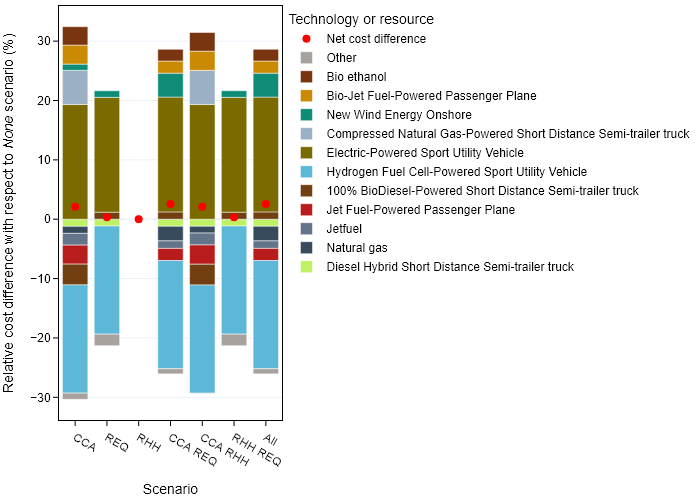

In [50]:
plot_cost_difference(
    df_f_mult=df_f_mult,
    df_annual_res=df_annual_res,
    cutoff=1.0, # [%]
    relative=True,
    save_results=save_results,
)

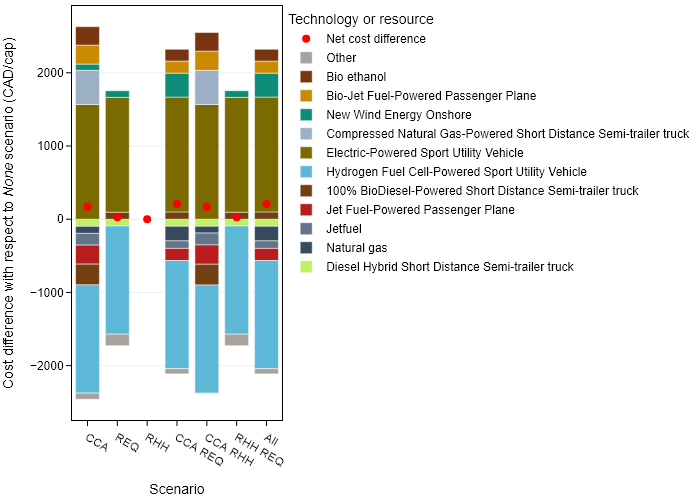

In [51]:
plot_cost_difference(
    df_f_mult=df_f_mult,
    df_annual_res=df_annual_res,
    cutoff=1.0, # [%]
    relative=False,
    save_results=save_results,
)